In [50]:
from data import build_all
from distances import compute_euclidean_distances, compute_mahalanobis_distances
from arsenal import compare_all_arsenals, arsenal_internal_distances, real_arsenal_silhouette_scores, PITCH_CHAR_FEATURES
from biomech import evaluate_biomech_features, biomech_threshold_coverage, biomech_threshold_calibration, plot_threshold_calibration
from stability import stability_analysis, plot_stability


import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

In [51]:
import importlib
import arsenal

importlib.reload(arsenal)

<module 'arsenal' from '/Users/kids/Pitcher Similarity/arsenal.py'>

In [52]:
data = build_all(live=False)

statcast_clean  = data['statcast_clean']
pitch_type_summ = data['pitch_type_summ']
pitcher_summ    = data['pitcher_summ']
pitcher_summ_r  = data['pitcher_summ_r']
pitcher_summ_l  = data['pitcher_summ_l']
pitch_type_r  = data['pitch_type_r']
pitch_type_l  = data['pitch_type_l']

statcast_clean_25 = statcast_clean[statcast_clean['game_year'] == 2025]

In [53]:
pitch_type_summ.head()

,pitch_type,pitcher,player_name,p_throws,game_year,release_speed,release_pos_x,release_pos_z,pfx_x,pfx_z,release_spin_rate,release_extension,release_pos_y,spin_axis,arm_angle,n
0,CH,425794,"Wainwright, Adam",R,2021,82.729744,-1.333487,6.222359,-1.152821,0.643179,1714.097938,6.495897,54.000974,222.546392,43.993229,195
1,CH,425794,"Wainwright, Adam",R,2022,82.182540,-1.314709,6.223757,-1.192593,0.668889,1763.634921,6.424339,54.075979,225.285714,42.871429,189
2,CH,425794,"Wainwright, Adam",R,2023,81.431461,-1.335618,6.142360,-1.168652,0.729663,1655.179775,6.511236,53.991685,225.898876,42.803529,89
3,CH,425844,"Greinke, Zack",R,2021,86.350791,-1.371002,6.311160,-1.065747,0.371793,1593.499115,5.907381,54.591810,225.651327,43.748592,569
4,CH,425844,"Greinke, Zack",R,2022,86.468984,-1.825642,6.142861,-1.067433,0.317032,1643.493298,5.916845,54.583316,229.329759,39.724722,374


# Pitch Characteristics

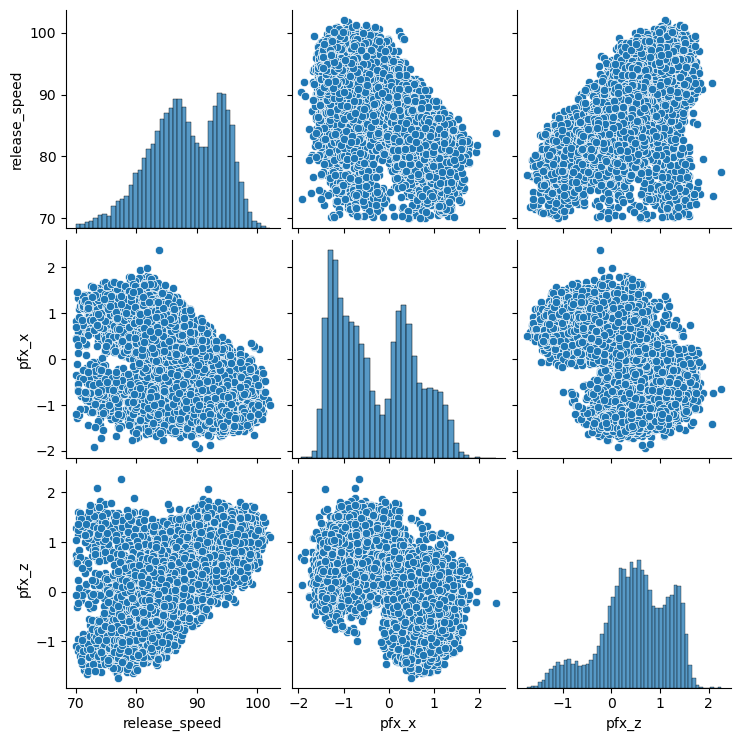

In [54]:
sns.pairplot(
    pitch_type_r,
    vars=["release_speed", "pfx_x", "pfx_z"],
    #hue="pitch_type"
);

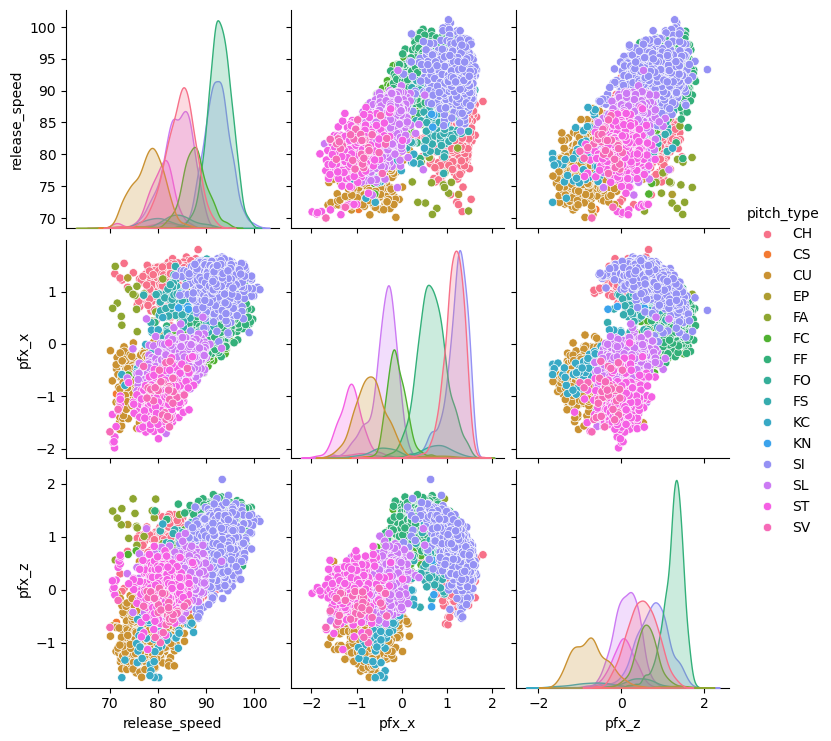

In [55]:
sns.pairplot(
    pitch_type_l,
    vars=["release_speed", "pfx_x", "pfx_z"],
    hue="pitch_type"
);

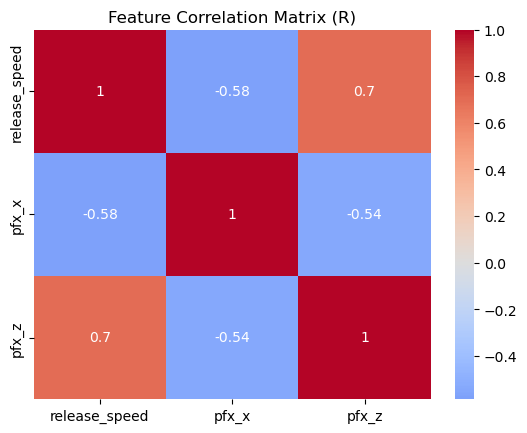

In [56]:
corr_r = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_r, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

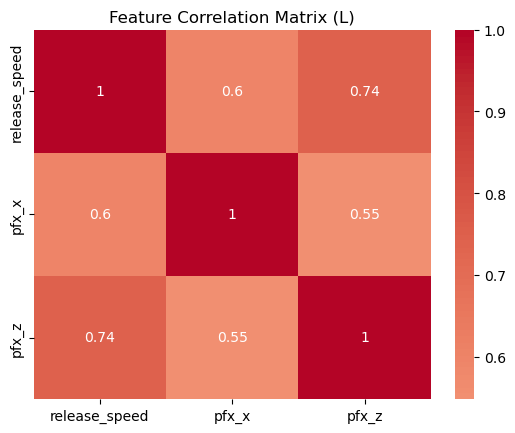

In [57]:
corr_l = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].corr()

sns.heatmap(corr_l, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

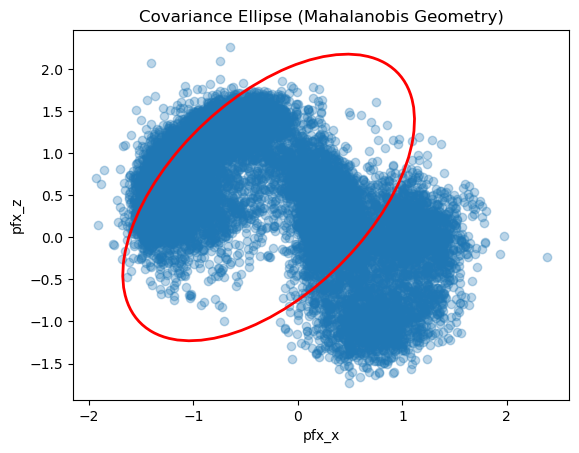

In [58]:
X = pitch_type_r[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

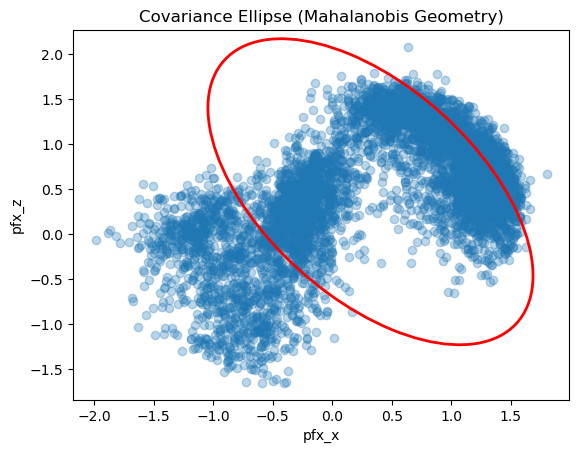

In [59]:
X = pitch_type_l[["pfx_x", "pfx_z"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("pfx_x")
ax.set_ylabel("pfx_z")
plt.title("Covariance Ellipse (Mahalanobis Geometry)")
plt.show()

In [60]:
X = pitch_type_r[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    0.025699
pfx_x            0.005587
pfx_z            0.006188
dtype: float64

In [61]:
X = pitch_type_l[["release_speed", "pfx_x", "pfx_z"]].dropna().values
VI = np.linalg.pinv(np.cov(X, rowvar=False))

def mahalanobis_components(x, y, VI):
    diff = x - y
    return diff * (VI @ diff)

# Example: inspect a weird pair
i, j = 0, 1  # replace with a suspicious pair
comp = mahalanobis_components(X[i], X[j], VI)

pd.Series(comp, index=["release_speed", "pfx_x", "pfx_z"])

release_speed    1.732206
pfx_x            0.009114
pfx_z           -0.034061
dtype: float64

# Biomechanics Characteristics

In [62]:
pitcher_summ_r.head()

,pitcher,p_throws,player_name,game_year,release_pos_x,release_pos_z,release_extension,arm_angle,n,max_velo,max_spin,pri_fb,fb_pfx_x,fb_n,pri_fb_cd,active_spin_fastball,FB_type
0,425794,R,"Wainwright, Adam",2021,-1.195318,6.292470,6.478433,46.499203,3037,89.050985,2840.411298,SI,-1.061773,863.0,0,76.4,FF
1,425794,R,"Wainwright, Adam",2022,-1.119490,6.303870,6.419000,46.148490,3080,88.566476,2777.854856,SI,-1.085446,874.0,0,75.8,FF
2,425794,R,"Wainwright, Adam",2023,-1.246479,6.218935,6.475293,45.361083,1690,86.875000,2663.096110,SI,-1.104411,560.0,0,76.9,FF
3,425844,R,"Greinke, Zack",2021,-1.271575,6.362570,5.938383,47.284900,2463,89.495973,2406.351852,FF,-0.107953,1026.0,1,78.7,FF
4,425844,R,"Greinke, Zack",2022,-1.725025,6.204550,5.905016,42.991710,2213,89.450000,2447.595238,FF,-0.173206,867.0,1,79.2,FF


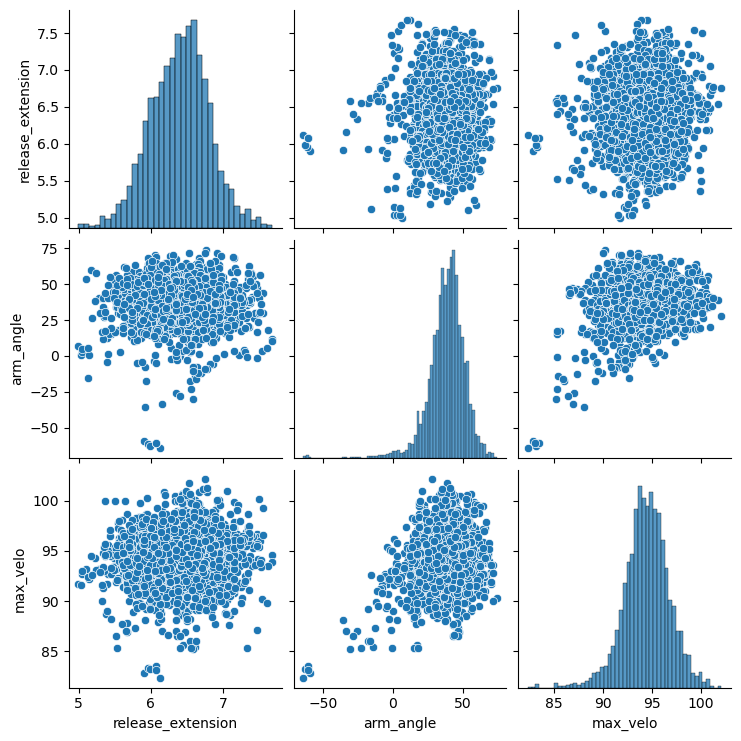

In [63]:
sns.pairplot(
    pitcher_summ_r[pitcher_summ_r['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

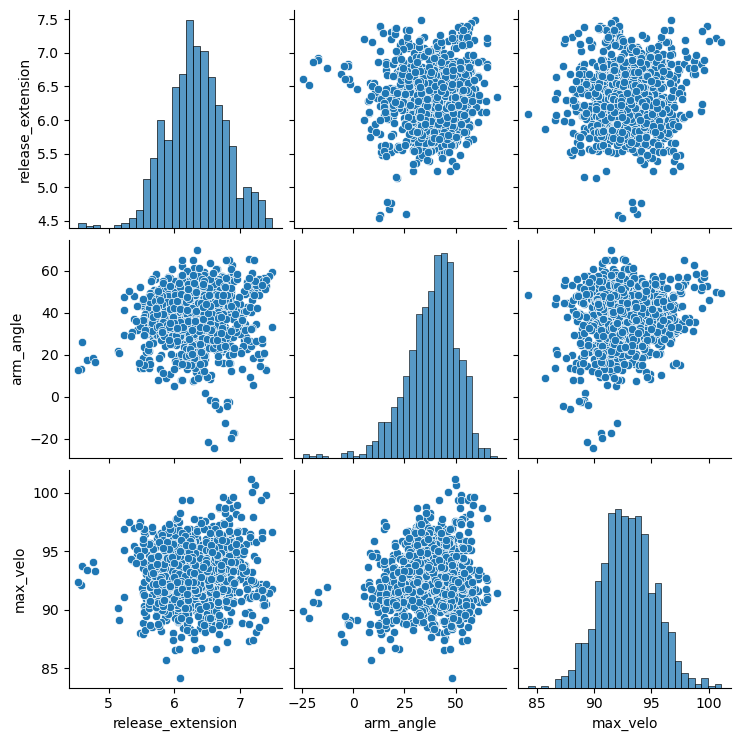

In [64]:
sns.pairplot(
    pitcher_summ_l[pitcher_summ_l['n']>100],
    vars=['release_extension', 'arm_angle', 'max_velo'],
);

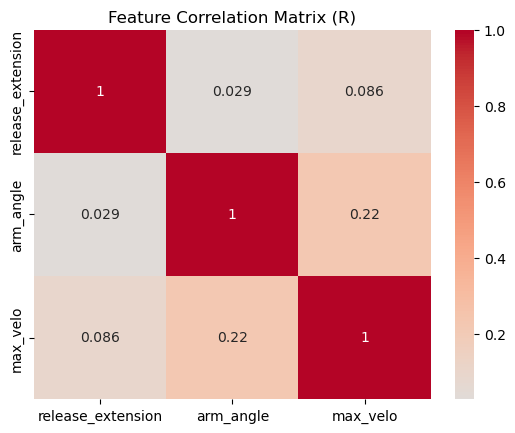

In [65]:
corr = pitcher_summ_r[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (R)");

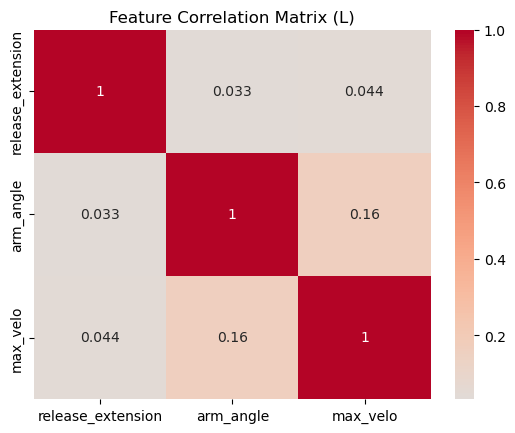

In [66]:
corr = pitcher_summ_l[['release_extension', 'arm_angle', 'max_velo']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (L)");

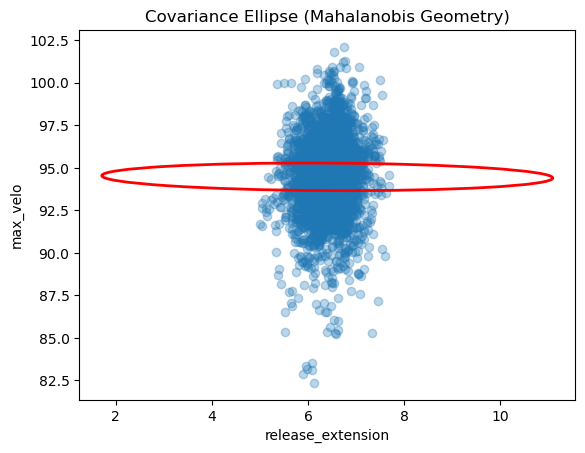

In [67]:
X = pitcher_summ_r[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

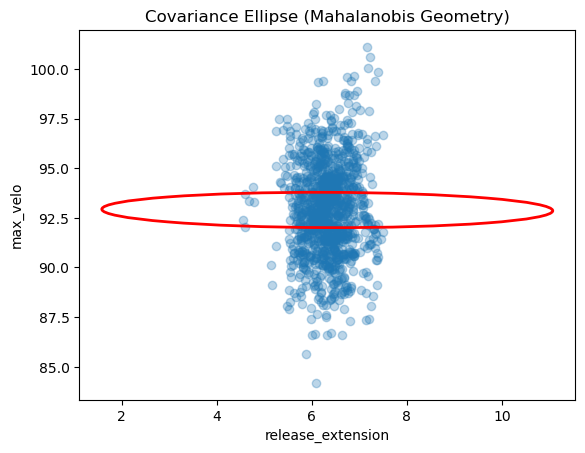

In [68]:
X = pitcher_summ_l[["release_extension", "max_velo"]].dropna().values
cov = np.cov(X, rowvar=False)
mean = X.mean(axis=0)

eigvals, eigvecs = np.linalg.eigh(cov)

angle = np.degrees(np.arctan2(*eigvecs[:,1][::-1]))

fig, ax = plt.subplots()
ax.scatter(X[:,0], X[:,1], alpha=0.3)

ellipse = Ellipse(
    xy=mean,
    width=2*np.sqrt(eigvals[0])*2,
    height=2*np.sqrt(eigvals[1])*2,
    angle=angle,
    edgecolor='red',
    fc='None',
    lw=2
)

ax.add_patch(ellipse)
ax.set_xlabel("release_extension")
ax.set_ylabel("max_velo")
plt.title("Covariance Ellipse (Mahalanobis Geometry)");

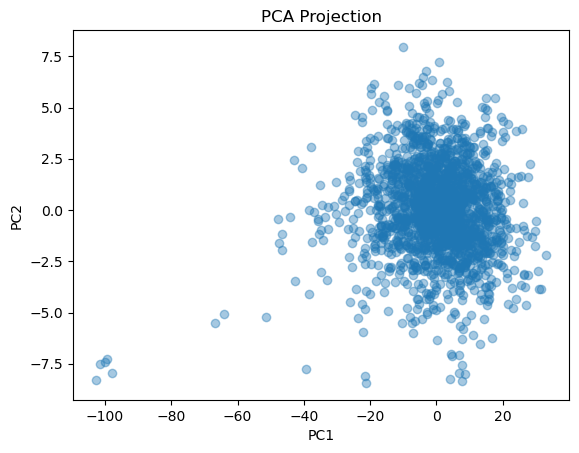

In [69]:
X = pitcher_summ_r[pitcher_summ_r['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

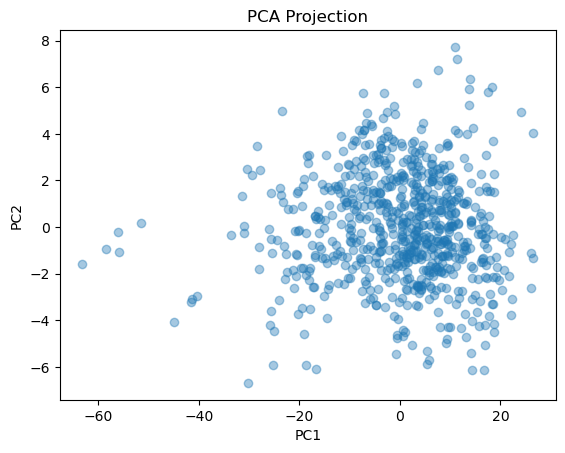

In [70]:
X = pitcher_summ_l[pitcher_summ_l['n']>500][['release_extension', 'arm_angle', 'max_velo']].dropna().values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.4)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection");

# Hyperparameter Optimization

## Data Prep

In [71]:
pitch_type_distance_r = compute_euclidean_distances(pitch_type_r, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)
pitch_type_distance_l = compute_euclidean_distances(pitch_type_l, 
                                                    features=["release_speed", "pfx_x", "pfx_z"], 
                                                    label_cols=["player_name", "pitch_type", "game_year"], 
                                                    min_pitches = 20)

Filter to 2025 data only for practical purposes

In [72]:
pitch_type_distance_r_25 = pitch_type_distance_r[(pitch_type_distance_r['game_year1']==2025) & 
    (pitch_type_distance_r['game_year2']==2025)]
pitch_type_distance_l_25 = pitch_type_distance_l[(pitch_type_distance_l['game_year1']==2025) & 
    (pitch_type_distance_l['game_year2']==2025)]

In [73]:
arsenal_comp_l_25 = compare_all_arsenals(pitch_type_distance_l_25, 50)
arsenal_comp_r_25 = compare_all_arsenals(pitch_type_distance_r_25, 50)

2.0149935279678877
2.0165904405253183


In [74]:
arsenal_comp_l_25

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
0,"Akin, Keegan",2025,"Bowden, Ben",2025,0.247601
1,"Burke, Brock",2025,"Peralta, Wandy",2025,0.249260
2,"Perdomo, Angel",2025,"Walker, Josh",2025,0.308990
3,"Perdomo, Angel",2025,"Poche, Colin",2025,0.331268
4,"Harrison, Kyle",2025,"Shuster, Jared",2025,0.341816
...,...,...,...,...,...
20095,"Morán, Jovani",2025,"Young, Danny",2025,2.642421
20096,"Cosgrove, Tom",2025,"Montgomery, Mason",2025,2.648327
20097,"Bruihl, Justin",2025,"Cruz, Omar",2025,2.653048
20098,"Bruihl, Justin",2025,"Montgomery, Mason",2025,2.681802


## Define Biomechanics

In [75]:
feature_sets = {
    'current (ext + arm_angle + max_velo + max_spin)':
       ['release_extension', 'arm_angle', 'max_velo', 'max_spin'],
    'current (ext + arm_angle + max_velo)':
       ['release_extension', 'arm_angle', 'max_velo'],
    'current (ext + arm_angle + max_velo + fb_pfx_x)':
       ['release_extension', 'arm_angle', 'max_velo', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + pri_fb_cd)':
        ['release_extension', 'arm_angle', 'max_velo', 'pri_fb_cd'],
    'current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'release_pos_x', 'release_pos_z', 'fb_pfx_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_z'],
    'current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)':
        ['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball', 'release_pos_x', 'release_pos_z'],
}

In [76]:
pitcher_summ_r_25 = pitcher_summ_r[pitcher_summ_r['game_year']==2025]
pitcher_summ_l_25 = pitcher_summ_l[pitcher_summ_l['game_year']==2025]

In [77]:
results_r_euc = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("RHP:\n", results_r_euc.to_string(index=False))

results_l_euc = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_euclidean_distances)
print("\nLHP:\n", results_l_euc.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3582      0.0   142311
                                            current (ext + arm_angle + max_velo + max_spin)        0.3681      0.0   142311
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3719      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3746      0.0   141246
                                                       current (ext + arm_angle + max_velo)        0.3790      0.0   142311
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3808      0.0   141246
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3863      0.0   141246
cu

In [78]:
results_r_mah = evaluate_biomech_features(pitcher_summ_r_25, 
                                          arsenal_comp_r_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("RHP:\n", results_r_mah.to_string(index=False))

results_l_mah = evaluate_biomech_features(pitcher_summ_l_25, 
                                          arsenal_comp_l_25, 
                                          feature_sets, 
                                          min_pitches=20,
                                          distance_fn=compute_mahalanobis_distances)
print("\nLHP:\n", results_l_mah.to_string(index=False))

RHP:
                                                                                    features  spearman_rho  p_value  n_pairs
            current (ext + arm_angle + max_velo + release_pos_x + release_pos_z + fb_pfx_x)        0.3026      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_z + fb_pfx_x)        0.3200      0.0   141246
                            current (ext + arm_angle + max_velo + release_pos_x + fb_pfx_x)        0.3323      0.0   141246
                                           current (ext + arm_angle + max_velo + pri_fb_cd)        0.3410      0.0   142311
current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_x + release_pos_z)        0.3480      0.0   142311
                                            current (ext + arm_angle + max_velo + fb_pfx_x)        0.3578      0.0   141246
                current (ext + arm_angle + max_velo + active_spin_fastball + release_pos_z)        0.3633      0.0   142311
  

**No matter how you slice it, extension, arm angle, max velocity, and active spin on the fastball are the best features to define biomechanics**

## Minimum Pitches Tuning

In [79]:
stability_df_biomech, raw_biomech = stability_analysis(statcast_clean_25, 
                                                    ['release_extension', 'arm_angle'],
                                                    sample_sizes = ([5,10,15,20,25,30]),
                                                    n_replicates=100,
                                                    n_pitchers=100
                                                    )

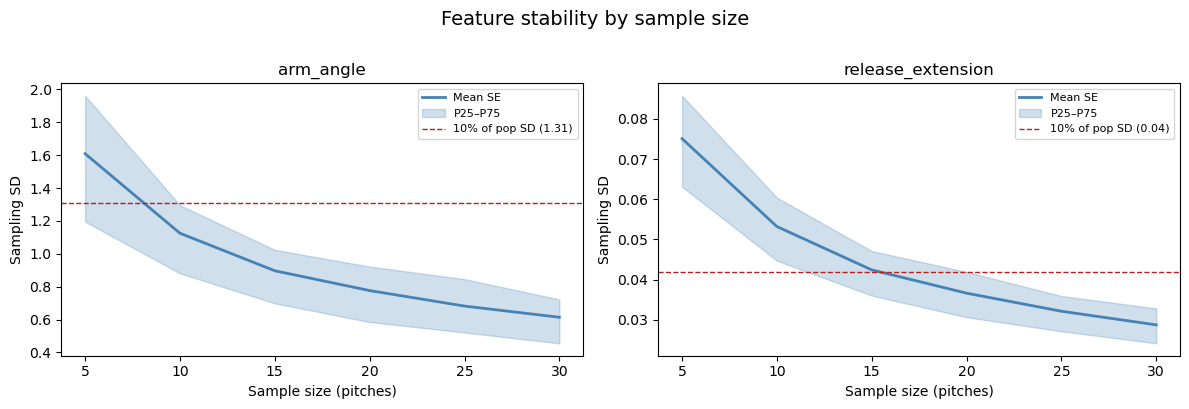

In [80]:
population_sds_biomech = {
    'arm_angle':         pitcher_summ['arm_angle'].std(),
    'release_extension': pitcher_summ['release_extension'].std(),
}
plot_stability(stability_df_biomech, population_sds_biomech)

In [81]:
stability_df_pitch, raw_pitch = stability_analysis(
    statcast_clean_25,
    features=['release_speed', 'pfx_x', 'pfx_z'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30]),
    n_replicates=100,
    n_pitchers=100
)

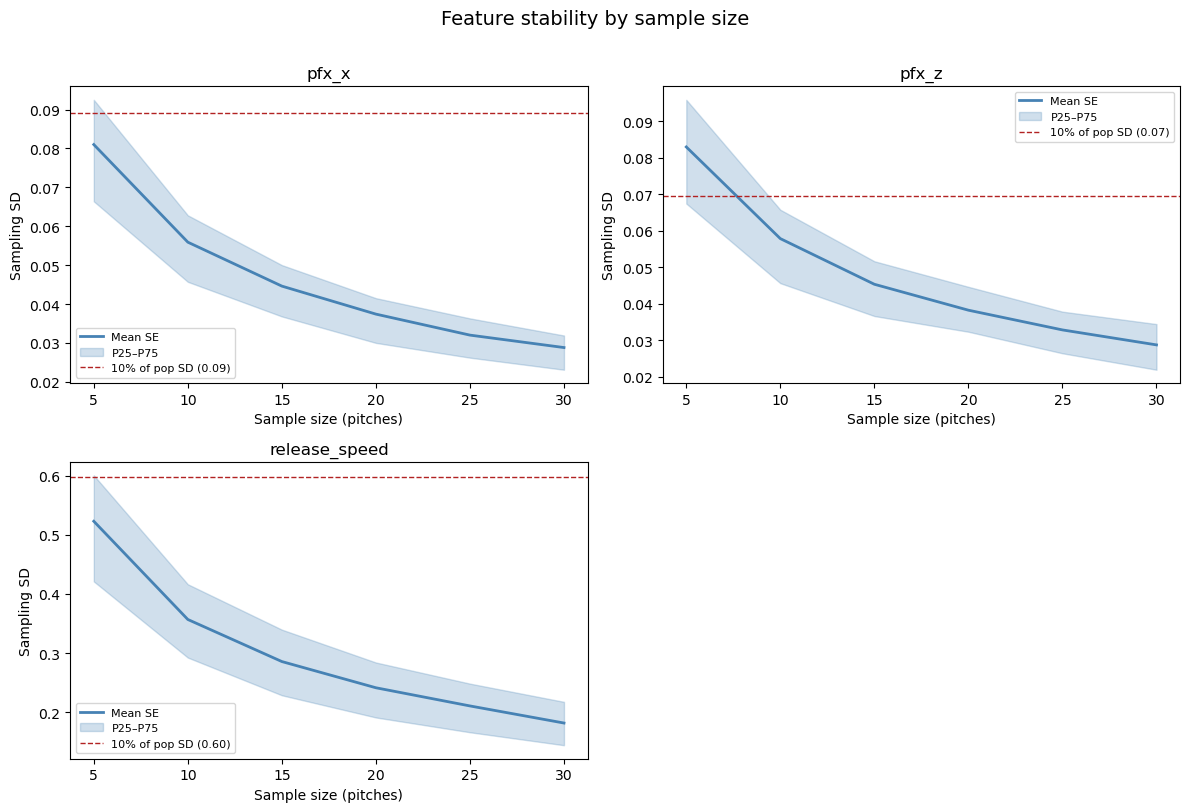

In [82]:
population_sds_pitch = {
    'release_speed': pitch_type_summ['release_speed'].std(),
    'pfx_x':         pitch_type_summ['pfx_x'].std(),
    'pfx_z':         pitch_type_summ['pfx_z'].std(),
}
plot_stability(stability_df_pitch, population_sds_pitch)

In [83]:
stability_df_pitch_ff, raw_pitch_ff = stability_analysis(
    statcast_clean_25[statcast_clean_25['pitch_type']=='FF'],
    features=['release_speed'],
    group_by_pitch_type=True,
    sample_sizes = ([5,10,15,20,25,30,35,40]),
    n_replicates=100,
    n_pitchers=100
)

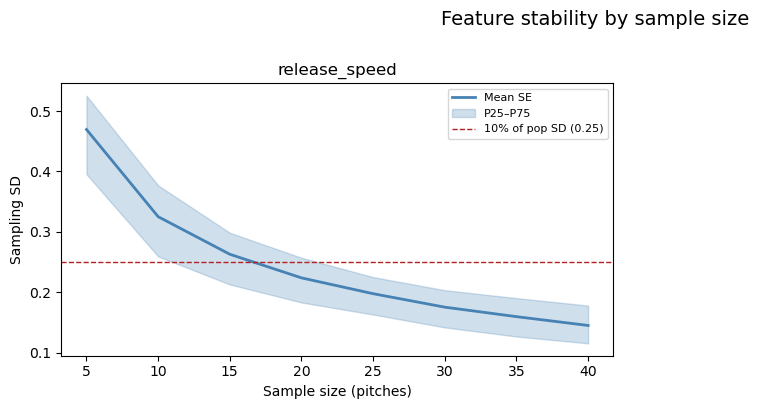

In [84]:
pitch_type_summ_ff = pitch_type_summ[pitch_type_summ['pitch_type']=='FF']
population_sds_pitch_ff = {
    'release_speed': pitch_type_summ_ff['release_speed'].std()
}
plot_stability(stability_df_pitch_ff, population_sds_pitch_ff)

Both pitch characteristics and biomechanical features stabilize very quickly. The slowest features to stabilize are extension and fastball velocity, and even they are quite differentiable after 20 pitches. We will use 20 pitches as the minimum number of pitches for analysis going forward.

## Arsenal Minimum Distance

In [85]:
global_scaler = StandardScaler().fit(pitch_type_summ[PITCH_CHAR_FEATURES].dropna().values)
arsenal_df = arsenal_internal_distances(pitch_type_summ, global_scaler=global_scaler)

── Arsenal internal distances (across all pitcher-years) ──
       mean_min_dist  min_min_dist  p25_min_dist  p50_min_dist  p75_min_dist  p90_min_dist
count       4325.000      4325.000      4325.000      4325.000      4325.000      4325.000
mean           1.718         1.436         1.442         1.591         1.866         2.078
std            0.657         0.780         0.774         0.693         0.626         0.629
min            0.318         0.044         0.044         0.080         0.318         0.318
25%            1.284         0.911         0.922         1.146         1.452         1.648
50%            1.550         1.195         1.197         1.407         1.746         1.974
75%            1.952         1.753         1.753         1.798         2.102         2.409
max            5.590         5.590         5.590         5.590         5.590         5.590


Min_min_dist shows the minimum distance between any two pitches in an arsenal. For example, if a sinker and fastball are the two most similar pitches in an arsenal, their distance apart will be what goes into the min_min_dist. 

In contrast, the mean_min_dist calculates the mean of every pitch's closest neighbor (FF closest pitch, SI closest pitch, CH closest pitch, etc.)

Since the purpose of this evaluation is to define the minimum threshold for uniqueness to add to an arsenal, I will use the median min_min_dist of about 1.2 as a conservative estimate, meaning that if there is a suggestion for a new pitch, it must be at least as far from every pitch in the current arsenal as the median closest distance.

## Biomechanical Maximum Distance

In [86]:
cov_r = biomech_threshold_coverage(pitcher_summ_r, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        76.7          6         23         64        122       3.1      8.1
      1.25       145.4         15         54        131        228       1.7      4.9
      1.50       234.4         32        103        226        360       1.0      2.9
      1.75       336.6         62        177        343        502       0.5      1.9
      2.00       443.9        105        275        475        630       0.2      1.5


In [87]:
cov_l = biomech_threshold_coverage(pitcher_summ_l, 
                                   thresholds=(1.0, 1.25, 1.5, 1.75, 2.0),
                                   min_pitches=20)

── Biomech threshold coverage ──
 threshold  mean_comps  p10_comps  p25_comps  p50_comps  p75_comps  pct_zero  pct_lt5
      1.00        24.3          2          8         20         38       4.1     16.4
      1.25        46.1          5         17         41         71       1.9      8.8
      1.50        75.2         12         34         69        113       1.1      4.4
      1.75       108.6         23         56        108        159       0.5      3.3
      2.00       145.3         42         85        150        205       0.3      1.9


Find examples of pitchers 1.5 apart


In [88]:
biomech_dist_l = compute_euclidean_distances(
    pitcher_summ_l,
    features=['release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball'],
    label_cols=['player_name', 'game_year'],
    min_pitches=20,
    include_features=True
)

In [100]:
biomech_dist_l[(biomech_dist_l['distance']>1.49999) & (biomech_dist_l['distance']<1.50001)]

,player_name1,player_name2,game_year1,game_year2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
93902,"Okert, Steven","Sears, JP",2026,2022,1.499991,0.039324,0.160267,-0.312936,-1.290537,-0.770324,0.112373,0.183672,0.891124
93903,"Strahm, Matt","Prielipp, Connor",2024,2026,1.499995,-0.308038,-1.120417,-0.579314,0.100976,0.207824,1.008539,0.911630,0.214431
93904,"Benjamin, Wes","Skubal, Tarik",2021,2021,1.499997,-0.800941,-0.253681,0.986449,1.040560,-0.680979,0.664878,0.921883,0.552778
93905,"Matzek, Tyler","Suarez, Ranger",2021,2023,1.500002,0.007264,-0.122322,1.103243,0.146522,1.320046,0.201029,-0.113663,-0.369986
93906,"Ferguson, Caleb","Allen, Logan",2022,2021,1.500003,-0.483107,-0.786840,-0.097412,0.653076,0.817961,-0.065472,-0.534033,0.368225
93907,"Coulombe, Danny","Sheffield, Justus",2021,2021,1.500004,-1.424420,-1.081745,0.982759,0.415414,-1.053761,0.177262,-1.231231,-0.687826
93908,"Hand, Brad","Ellard, Fraser",2023,2025,1.500006,-1.176721,-0.237545,-0.223893,-0.838330,-0.090559,0.862341,-0.093157,-0.380239


In [103]:
biomech_dist_l[((biomech_dist_l['player_name1']=='Suarez, Ranger') & (biomech_dist_l['player_name2']=='Waddell, Brandon') &
                 (biomech_dist_l['game_year1']==2023) & (biomech_dist_l['game_year2']==2025))]

,player_name1,player_name2,game_year1,game_year2,distance,release_extension1,release_extension2,arm_angle1,arm_angle2,max_velo1,max_velo2,active_spin_fastball1,active_spin_fastball2
95376,"Suarez, Ranger","Waddell, Brandon",2023,2025,1.508444,-0.122322,-0.451672,0.146522,0.197158,0.201029,-0.812559,-0.369986,-1.43629


In [105]:
pitcher_summ_l[((pitcher_summ_l['player_name']=='Strahm, Matt') & (pitcher_summ_l['game_year']==2024)) |
                 ((pitcher_summ_l['player_name']=='Prielipp, Connor') & (pitcher_summ_l['game_year']==2026))][['player_name', 'game_year', 'release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']].round(1)

,player_name,game_year,release_extension,arm_angle,max_velo,active_spin_fastball
1312,"Strahm, Matt",2024,6.2,30.8,93.4,98.0
3812,"Prielipp, Connor",2026,5.8,39.5,95.3,91.2


In [106]:
pitcher_summ_l[((pitcher_summ_l['player_name']=='Suarez, Ranger') & (pitcher_summ_l['game_year']==2023)) |
                 ((pitcher_summ_l['player_name']=='Waddell, Brandon') & (pitcher_summ_l['game_year']==2025))][['player_name', 'game_year', 'release_extension', 'arm_angle', 'max_velo', 'active_spin_fastball']].round(1)

,player_name,game_year,release_extension,arm_angle,max_velo,active_spin_fastball
1446,"Suarez, Ranger",2023,6.3,40.0,93.4,85.5
2280,"Waddell, Brandon",2025,6.1,40.7,91.0,75.1


In [91]:
biomech_thresh_l = biomech_threshold_calibration(
    pitcher_summ_l_25,
    arsenal_comp_l_25,
    min_pitches=20,
    n_bins=10,
    max_biomech_dist=3.0,
)

── Biomech threshold calibration ──
 biomech_bin_mid  mean_arsenal  median_arsenal  n_pairs
           0.289        1.0577          0.9901       36
           0.576        1.0223          1.0054      169
           0.861        1.0611          1.0681      481
           1.146        1.1181          1.1203      828
           1.432        1.1287          1.1390     1329
           1.716        1.1769          1.1849     1617
           2.002        1.2212          1.2313     1885
           2.287        1.2618          1.2654     1843
           2.572        1.2960          1.3012     1747
           2.858        1.3568          1.3615     1552


In [92]:
biomech_thresh_r = biomech_threshold_calibration(
    pitcher_summ_r_25,
    arsenal_comp_r_25,
    min_pitches=20,
    n_bins=10,
    max_biomech_dist=3.0,
)

── Biomech threshold calibration ──
 biomech_bin_mid  mean_arsenal  median_arsenal  n_pairs
           0.227        1.0641          1.0737      160
           0.520        1.0835          1.0970     1263
           0.812        1.1082          1.1117     3827
           1.103        1.1211          1.1292     7816
           1.395        1.1593          1.1703    11809
           1.687        1.1882          1.1978    15005
           1.979        1.2197          1.2301    16638
           2.270        1.2584          1.2663    16794
           2.562        1.2954          1.3055    15495
           2.854        1.3268          1.3351    13056


In [93]:
arsenal_comp_r_25.head()

,player_name1,game_year1,player_name2,game_year2,arsenal_distance
0,"Rainey, Tanner",2025,"Romano, Jordan",2025,0.159637
1,"Burr, Ryan",2025,"Poteet, Cody",2025,0.162176
2,"Ginkel, Kevin",2025,"Thompson, Mason",2025,0.168337
3,"Mercado, Michael",2025,"Stephenson, Robert",2025,0.176231
4,"Gillaspie, Logan",2025,"Sanders, Cam",2025,0.189609


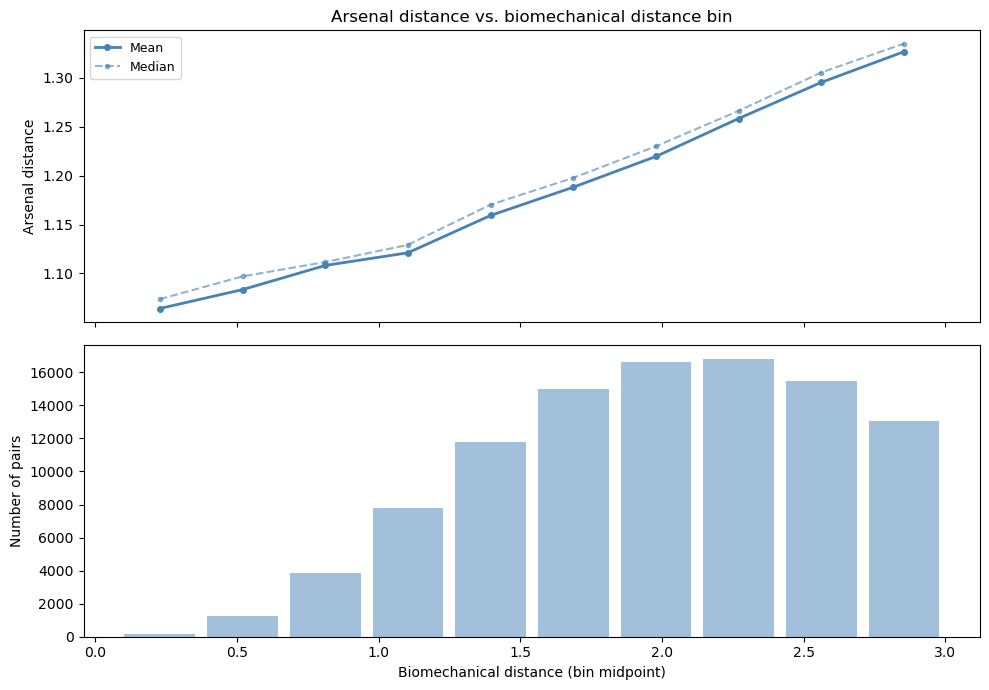

In [94]:
plot_threshold_calibration(biomech_thresh_r)

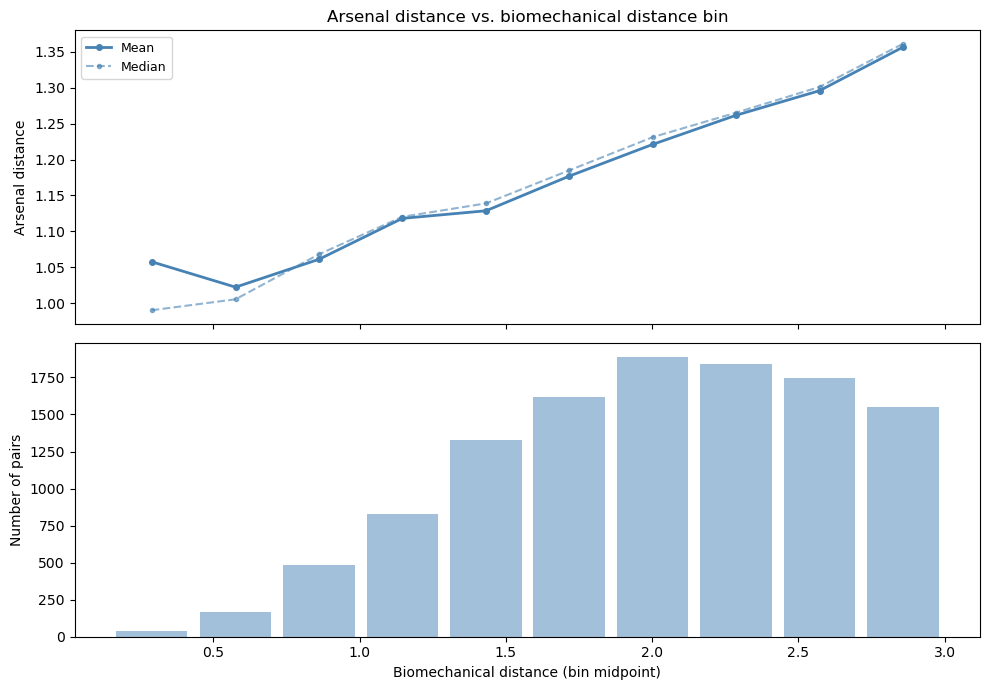

In [95]:
plot_threshold_calibration(biomech_thresh_l)

Going to use 1.5 as a threshold due to solid evidence from both charts. The bottom one shows 1.5 as just before hitting the mass of the data and the biomech_thresh stuff shows 1.5 as a solid compromise. Looking at specific examples validates 1.5 as a good edge case.